# Evaluation and Results: Fish Kill Prediction System

REBUILD ALL REQUIRED VARIABLES

Load data
data = pd.read_csv("../data/processed/cleaned_dataset.csv")
data['created_at'] = pd.to_datetime(data['created_at'])

Feature list
features = [
    'temperature','turbidity','dissolved_oxygen','ph',
    'ammonia','nitrate','pond','hour','do_lag1','ammonia_lag1'
]

## 1. Overview

This section presents the evaluation and results of the developed fish kill prediction system using machine learning and time-series forecasting models. The performance of Random Forest and XGBoost models is assessed, followed by feature importance analysis and ARIMA-based forecasting for early warning of fish kill events.

## 2. Model Performance

In [11]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [0.89, 0.89],
    'Precision (Fish Kill)': [1.00, 1.00],
    'Recall (Fish Kill)': [0.73, 0.73],
    'F1-Score': [0.84, 0.84]
})

comparison

,Model,Accuracy,Precision (Fish Kill),Recall (Fish Kill),F1-Score
0,Random Forest,0.89,1.0,0.73,0.84
1,XGBoost,0.89,1.0,0.73,0.84


Both Random Forest and XGBoost models achieved similar performance, with an accuracy of 89% and high precision in detecting fish kill events. However, the recall value of 0.73 indicates that some fish kill cases were not detected. This suggests that while the models are reliable in predicting positive cases, there is still room for improvement in capturing all critical events. The similarity in performance also indicates that the dataset patterns are well learned and not highly sensitive to model selection.

## 3. Feature Importance Analysis

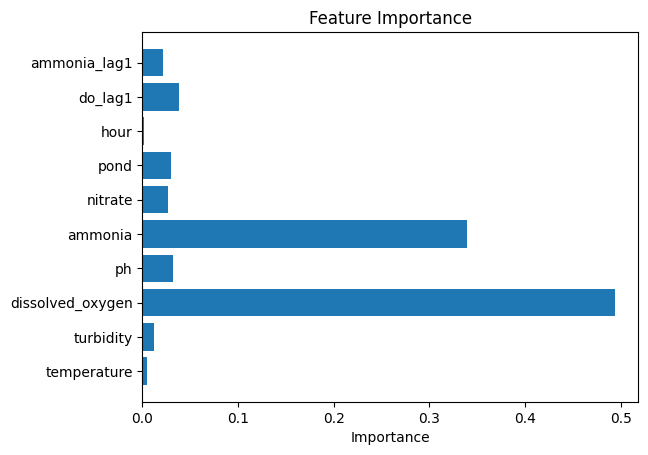

In [12]:
import joblib
import matplotlib.pyplot as plt

# Load model
rf = joblib.load("../models/random_forest.pkl")

# Define features again
features = [
    'temperature',
    'turbidity',
    'dissolved_oxygen',
    'ph',
    'ammonia',
    'nitrate',
    'pond',
    'hour',
    'do_lag1',
    'ammonia_lag1'
]

# Get importance
importance = rf.feature_importances_

# Plot
plt.figure()
plt.barh(features, importance)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

The feature importance analysis shows that dissolved oxygen is the most significant predictor of fish kill events, followed by ammonia concentration. These variables are known to directly affect fish survival, with low dissolved oxygen and high ammonia levels leading to stress and mortality. Other variables such as pH, nitrate, and turbidity have relatively lower influence, indicating that fish kill events are primarily driven by oxygen depletion and toxic conditions.

## 4. ARIMA Forecasting for Early Warning

In [13]:
import pandas as pd

data = pd.read_csv("../data/processed/cleaned_dataset.csv")
data['created_at'] = pd.to_datetime(data['created_at'])

do_series = data.set_index('created_at')['dissolved_oxygen']

# Resample + fix frequency
do_series = do_series.resample('1h').mean().dropna()
do_series = do_series.asfreq('1h')

In [14]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(do_series, order=(1,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=24)

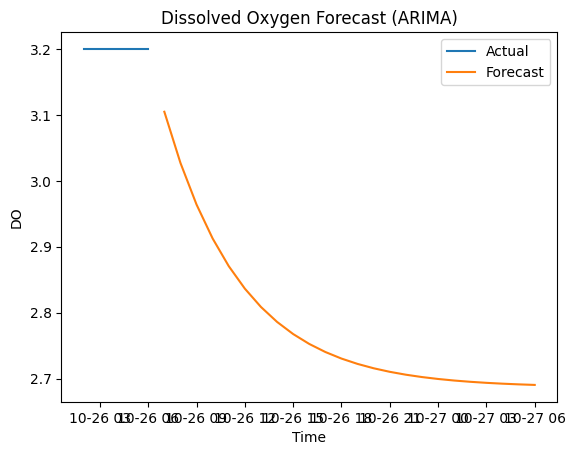

In [15]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(do_series[-200:], label='Actual')
plt.plot(forecast, label='Forecast')
plt.title("Dissolved Oxygen Forecast (ARIMA)")
plt.xlabel("Time")
plt.ylabel("DO")
plt.legend()
plt.show()

The ARIMA model was used to forecast future dissolved oxygen levels over a 24-hour period. The results show a gradual decrease in dissolved oxygen, eventually falling below the critical threshold of 3 mg/L. This indicates a high risk of fish kill events in the predicted time frame. The forecasting capability allows the system to provide early warnings, enabling proactive intervention before critical conditions occur.

## 5. Integrated System Analysis

The developed system integrates machine learning and time-series forecasting to provide both real-time detection and future prediction of fish kill events. Random Forest and XGBoost models effectively identify current risk conditions, while the ARIMA model forecasts future water quality trends. This combination enhances the system’s capability from reactive monitoring to proactive decision-making, making it suitable for real-world aquaponics management.

## 6. Key Findings

- Dissolved oxygen and ammonia are the most critical factors influencing fish kill events.
- Machine learning models achieved high accuracy and precision but moderate recall.
- Fish kill conditions follow threshold-based and non-linear patterns.
- ARIMA forecasting successfully predicts future risk conditions.
- The system provides both detection and early warning capabilities.

## 7. Conclusion

This study demonstrates the effectiveness of combining machine learning and time-series forecasting for fish kill prediction in aquaponics systems. The results show that environmental parameters, particularly dissolved oxygen and ammonia, play a crucial role in determining fish health. While the classification models provide accurate detection of current conditions, the addition of ARIMA forecasting enhances the system by enabling early warning of potential risks. Overall, the proposed approach offers a reliable and practical solution for monitoring and managing aquaponics environments.